In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt

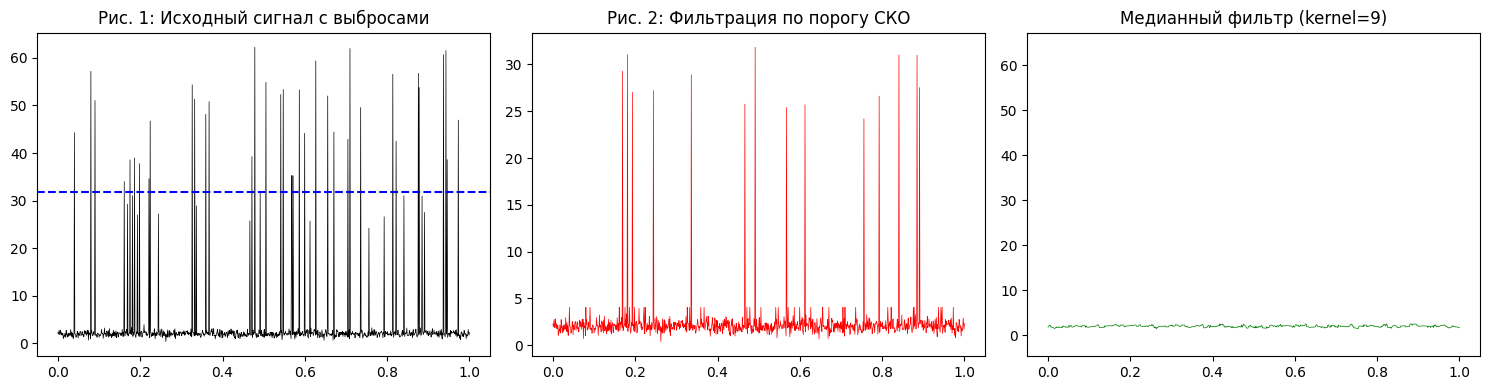

In [30]:
np.random.seed(42)
N = 1000
t = np.linspace(0, 1, N)
signal = np.random.randn(N) * 0.5 + 2

spike_indices = np.random.choice(N, 50, replace=False)
signal[spike_indices] += np.random.uniform(20, 60, 50)

mean = np.mean(signal)
std = np.std(signal)
threshold = mean + 3 * std

signal_std_filtered = signal.copy()
signal_std_filtered[signal_std_filtered > threshold] = mean

signal_med_filtered = medfilt(signal, kernel_size=9)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ylimits = (min(signal.min(), signal_med_filtered.min()) - 5, max(signal.max(), signal_med_filtered.max()) + 5)
axes[0].plot(t, signal, 'k', linewidth=0.5)
axes[0].axhline(threshold, color='blue', linestyle='--')
axes[0].set_title('Рис. 1: Исходный сигнал с выбросами')
axes[1].plot(t, signal_std_filtered, 'r', linewidth=0.5)
axes[1].set_title('Рис. 2: Фильтрация по порогу СКО')
axes[2].plot(t, signal_med_filtered, 'g', linewidth=0.5)
axes[2].set_title('Медианный фильтр (kernel=9)')
axes[2].set_ylim(ylimits)
plt.tight_layout()
plt.show()

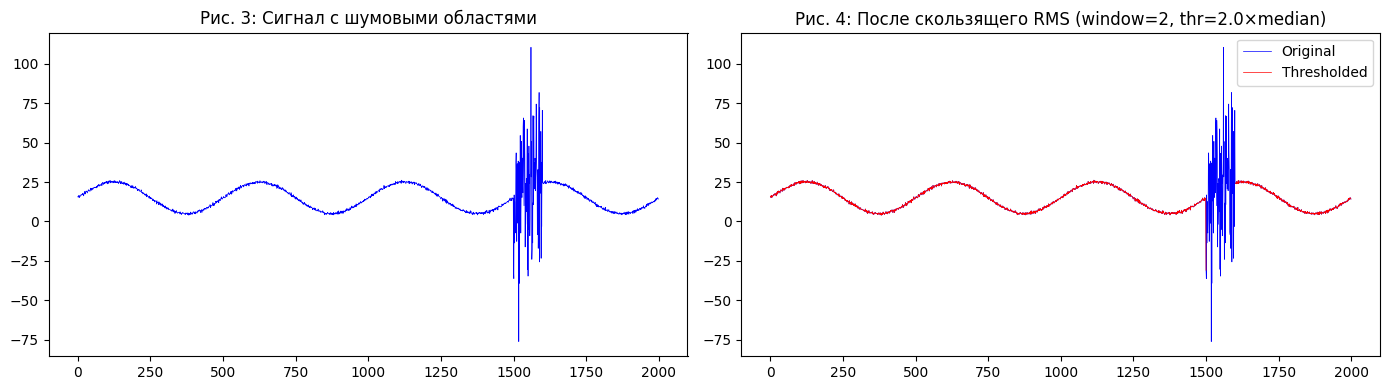

In [33]:
np.random.seed(0)
N = 2000
t2 = np.arange(N)
base = 10 * np.sin(2 * np.pi * t2 / 500) + 15
noise = np.random.randn(N) * 0.5

noisy_signal = base + noise
noisy_signal[1500:1600] += np.random.randn(100) * 30

window = 3
rms = np.zeros(N)
for i in range(N):
    seg = noisy_signal[max(0, i - window // 2):min(N, i + window // 2)]
    rms[i] = np.sqrt(np.mean(seg ** 2))

rms_threshold = np.median(rms) * 2.0

bad_mask = rms > rms_threshold
gap_start = int(np.where(bad_mask)[0][0])
gap_end = int(np.where(bad_mask)[0][-1]) + 1
cleaned = noisy_signal.copy().astype(float)
cleaned[gap_start:gap_end] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(t2, noisy_signal, 'b', linewidth=0.5)
axes[0].set_title('Рис. 3: Сигнал с шумовыми областями')
axes[1].plot(t2, noisy_signal, 'b', linewidth=0.5, label='Original')
axes[1].plot(t2, cleaned, 'r', linewidth=0.5, label='Thresholded')
axes[1].legend()
axes[1].set_title('Рис. 4: После скользящего RMS (window=2, thr=2.0×median)')
plt.tight_layout()
plt.show()

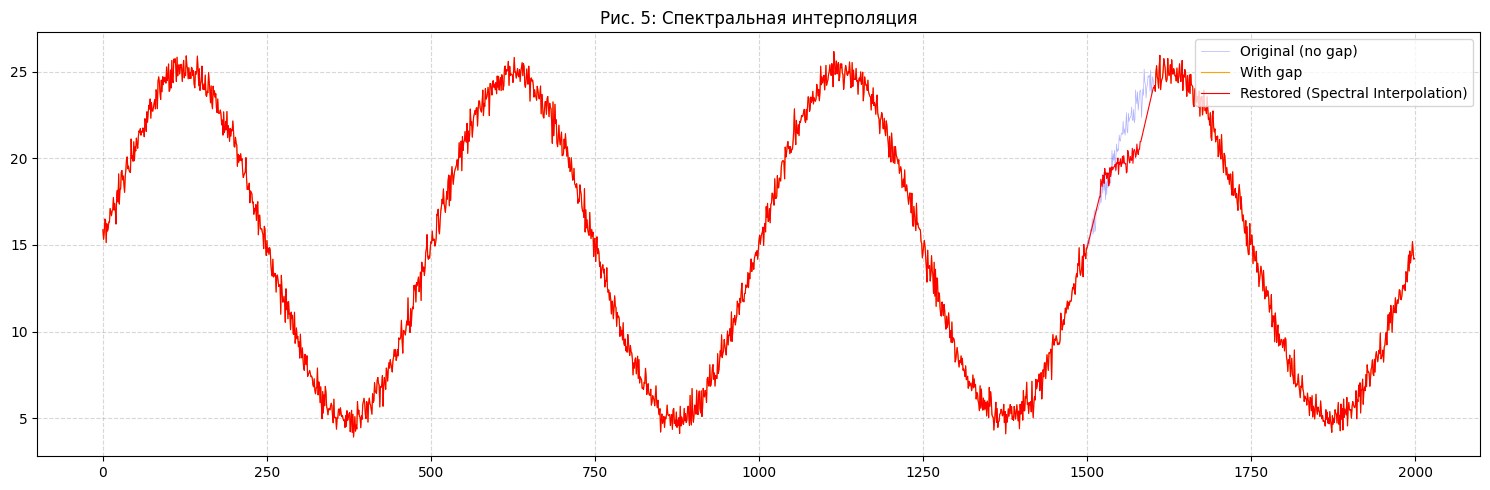

In [34]:
from scipy.signal import resample

expand = window // 2
gap_start_exp = max(0, gap_start - expand)
gap_end_exp = min(N, gap_end + expand)

cleaned[gap_start_exp:gap_end_exp] = np.nan
gap_len = gap_end_exp - gap_start_exp

win = min(gap_len, gap_start_exp, N - gap_end_exp)

left_seg  = noisy_signal[gap_start_exp - win : gap_start_exp]
right_seg = noisy_signal[gap_end_exp : gap_end_exp + win]

fft_left  = np.fft.fft(left_seg)
fft_right = np.fft.fft(right_seg)
avg_fft = (fft_left + fft_right) / 2

restored_gap = np.real(np.fft.ifft(avg_fft))
restored_gap -= np.mean(restored_gap)
restored_gap += (np.mean(left_seg[-5:]) + np.mean(right_seg[:5])) / 2
stitch_w = min(20, gap_len // 5)
restored_gap[:stitch_w]  = np.linspace(left_seg[-1],  restored_gap[stitch_w],       stitch_w)
restored_gap[-stitch_w:] = np.linspace(restored_gap[-stitch_w - 1], right_seg[0],   stitch_w)
restored = cleaned.copy()
restored[gap_start_exp:gap_end_exp] = restored_gap

plt.figure(figsize=(15, 5))
plt.plot(t2, base + noise, 'b', linewidth=0.5, label='Original (no gap)', alpha=0.3)
plt.plot(t2, cleaned, color='orange', linewidth=0.8, label='With gap')
plt.plot(t2, restored, 'r', linewidth=0.8, label='Restored (Spectral Interpolation)')
plt.legend()
plt.title('Рис. 5: Спектральная интерполяция')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

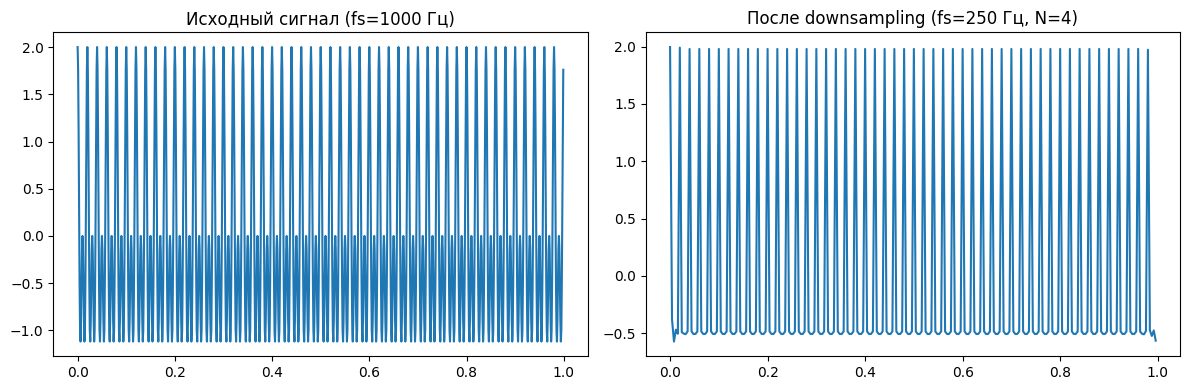

In [14]:
from scipy.signal import butter, filtfilt

fs = 1000
t4 = np.arange(0, 1, 1/fs)
sig4 = np.cos(2*np.pi*50*t4) + np.cos(2*np.pi*100*t4)

N_down = 4
fs_new = fs / N_down
nyq_new = fs_new / 2

b, a = butter(8, nyq_new / (fs / 2), btype='low')
sig_lp = filtfilt(b, a, sig4)
sig_down = sig_lp[::N_down]
t_down = t4[::N_down]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t4, sig4)
axes[0].set_title(f'Исходный сигнал (fs={fs} Гц)')
axes[1].plot(t_down, sig_down)
axes[1].set_title(f'После downsampling (fs={int(fs_new)} Гц, N={N_down})')
plt.tight_layout()
plt.show()

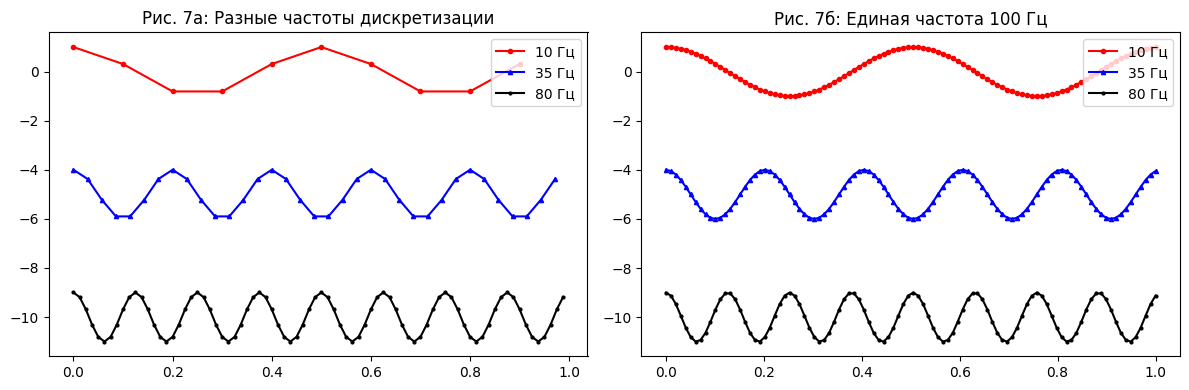

In [15]:
from scipy.signal import resample

fs1, fs2, fs3 = 10, 35, 80
duration = 1.0
target_fs = 100

t1 = np.arange(0, duration, 1/fs1)
t2_ = np.arange(0, duration, 1/fs2)
t3 = np.arange(0, duration, 1/fs3)

s1 = np.cos(2*np.pi*2*t1)
s2 = np.cos(2*np.pi*5*t2_) - 5
s3 = np.cos(2*np.pi*8*t3) - 10

target_len = int(duration * target_fs)
s1_r = resample(s1, target_len)
s2_r = resample(s2, target_len)
s3_r = resample(s3, target_len)
t_common = np.linspace(0, duration, target_len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t1, s1, 'ro-', ms=3, label=f'{fs1} Гц')
axes[0].plot(t2_, s2, 'b^-', ms=3, label=f'{fs2} Гц')
axes[0].plot(t3, s3, 'ko-', ms=2, label=f'{fs3} Гц')
axes[0].legend()
axes[0].set_title('Рис. 7а: Разные частоты дискретизации')
axes[1].plot(t_common, s1_r, 'ro-', ms=3, label=f'{fs1} Гц')
axes[1].plot(t_common, s2_r, 'b^-', ms=3, label=f'{fs2} Гц')
axes[1].plot(t_common, s3_r, 'ko-', ms=2, label=f'{fs3} Гц')
axes[1].legend()
axes[1].set_title(f'Рис. 7б: Единая частота {target_fs} Гц')
plt.tight_layout()
plt.show()